## L3 - Implementación de RN en Python
* Objetivo: Diseñar y entrenar una red neuronal con Python para
resolver un problema de clasificación.



In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import os

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

# Carpeta de resultados
os.makedirs("outputs", exist_ok=True)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [3]:
# Cargar dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Forma de x_train:", x_train.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de x_test:", x_test.shape)
print("Forma de y_test:", y_test.shape)

Forma de x_train: (60000, 28, 28)
Forma de y_train: (60000,)
Forma de x_test: (10000, 28, 28)
Forma de y_test: (10000,)


## Exploración inicial de imágenes

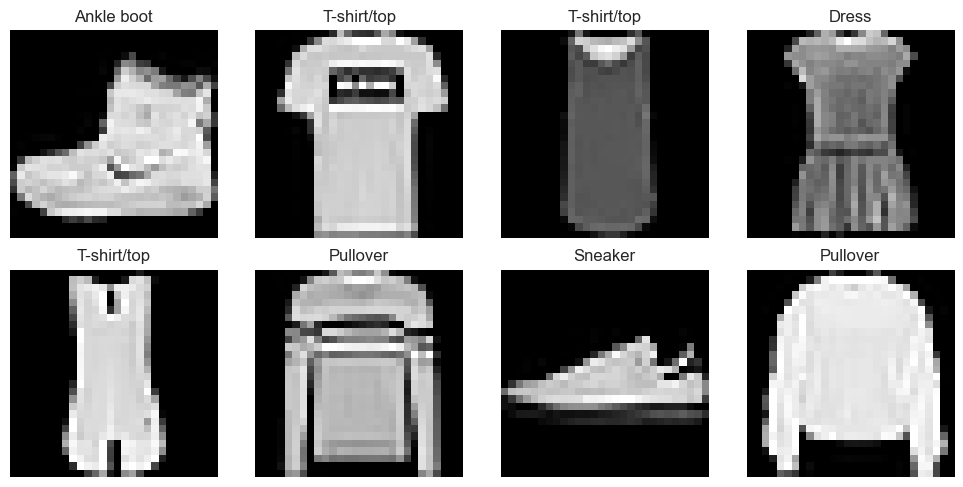

In [4]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(10, 5))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

Las imágenes corresponden a distintas prendas y accesorios de moda. Aunque son imágenes pequeñas y en escala de grises, contienen suficiente información visual para que una red neuronal aprenda patrones útiles de clasificación.

In [5]:
# Normalización
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [6]:
# Redimensionar para CNN
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Nueva forma de x_train:", x_train.shape)
print("Nueva forma de x_test:", x_test.shape)

Nueva forma de x_train: (60000, 28, 28, 1)
Nueva forma de x_test: (10000, 28, 28, 1)


## Codificación de etiquetas
Como se trata de una clasificación multiclase, se convierten las etiquetas en formato one-hot encoding

In [7]:
# One-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Ejemplo etiqueta original:", y_train[0])
print("Ejemplo etiqueta codificada:", y_train_cat[0])

Ejemplo etiqueta original: 9
Ejemplo etiqueta codificada: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


## Definición del modelo
Se implementa una red neuronal convulativa(CNN), adecuada para la clasificación de imágenes

In [8]:
# Modelo CNN
model_l3 = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(10, activation="softmax")
])

model_l3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compilación
model_l3.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Early stopping
# Para detener el entrenamiento cuando la pérdida de validación deje de mejorar
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Entrenamiento usando parte de los datos como validación
history_l3 = model_l3.fit(
    x_train, y_train_cat,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.8020 - loss: 0.5460 - val_accuracy: 0.8719 - val_loss: 0.3553
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8699 - loss: 0.3575 - val_accuracy: 0.8872 - val_loss: 0.3104
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.8881 - loss: 0.3056 - val_accuracy: 0.8963 - val_loss: 0.2789
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.8996 - loss: 0.2716 - val_accuracy: 0.9007 - val_loss: 0.2730
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9077 - loss: 0.2480 - val_accuracy: 0.9080 - val_loss: 0.2552
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9164 - loss: 0.2254 - val_accuracy: 0.9035 - val_loss: 0.2583
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.9218 - loss: 0.2103 - val_accuracy: 0.9093 - val_loss: 0.2484
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9261 -

## Evaluación del modelo

In [10]:
# Evaluación
loss, acc = model_l3.evaluate(x_test, y_test_cat, verbose=0)
print(f"Loss en test: {loss:.4f}")
print(f"Accuracy en test: {acc:.4f}")

Loss en test: 0.2545
Accuracy en test: 0.9074


In [ ]:
# Guardar métricas
with open("outputs/metricas.txt", "w") as f:
    f.write(f"Loss: {loss:.4f}\n")
    f.write(f"Accuracy: {acc:.4f}\n")

## Predicciones en conjunto de prueba

In [ ]:
# Predicciones sobre el conjunto de prueba
y_pred_prob = model_l3.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


## Reporte de clasificación

In [ ]:
# Reporte de clasificación
report = classification_report(y_test, y_pred, target_names=class_names)

# Guardamos reporte
with open("outputs/classification_report.txt", "w") as f:
    f.write(report)
    

El reporte permite observar precisión, recall y f1-score para cada categoría. Esto ayuda a identificar qué clases son reconocidas con mayor facilidad y cuáles presentan más dificultad.

## Matriz de confusión

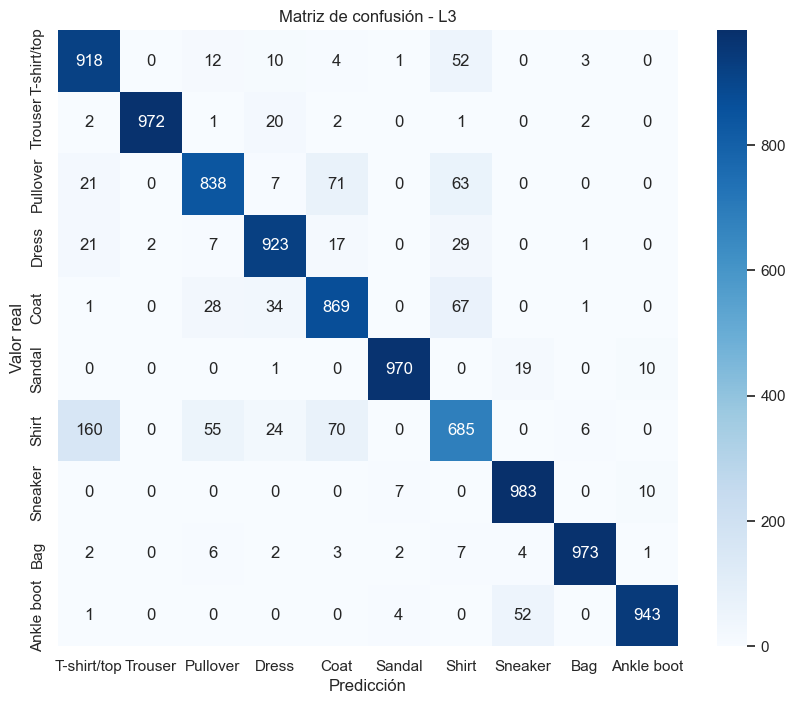

In [28]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Matriz de confusión - L3")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

plt.savefig("outputs/matriz_confusion.png")
plt.close()

La diagonal principal concentra las clasificaciones correctas. Los valores fuera de la diagonal muestran confusiones entre clases, por ejemplo, entre prendas visualmente parecidas como “Shirt”, “T-shirt/top” o “Pullover”.

## Visualización del entrenamiento

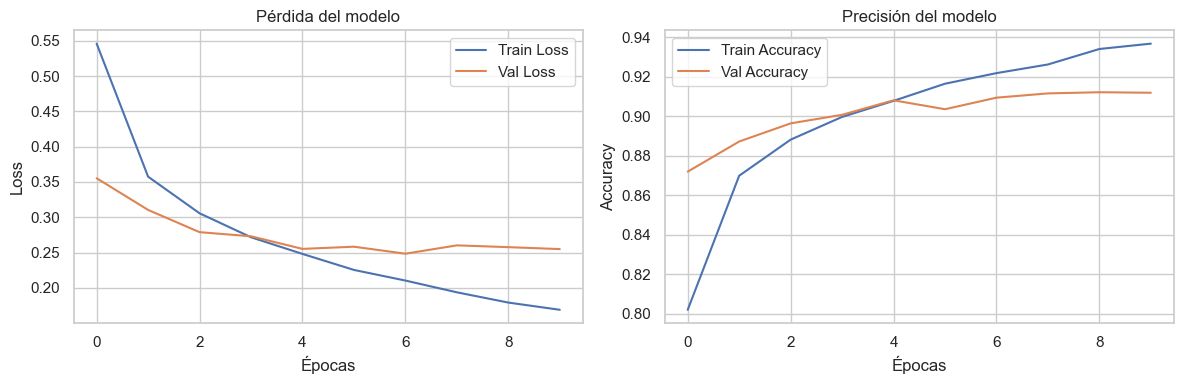

In [24]:
# Gráficas de entrenamiento
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_l3.history["loss"], label="Train Loss")
plt.plot(history_l3.history["val_loss"], label="Val Loss")
plt.title("Pérdida del modelo")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_l3.history["accuracy"], label="Train Accuracy")
plt.plot(history_l3.history["val_accuracy"], label="Val Accuracy")
plt.title("Precisión del modelo")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig("outputs/curvas_entrenamiento.png")
plt.show()

## Prueba de algunos resultados visuales

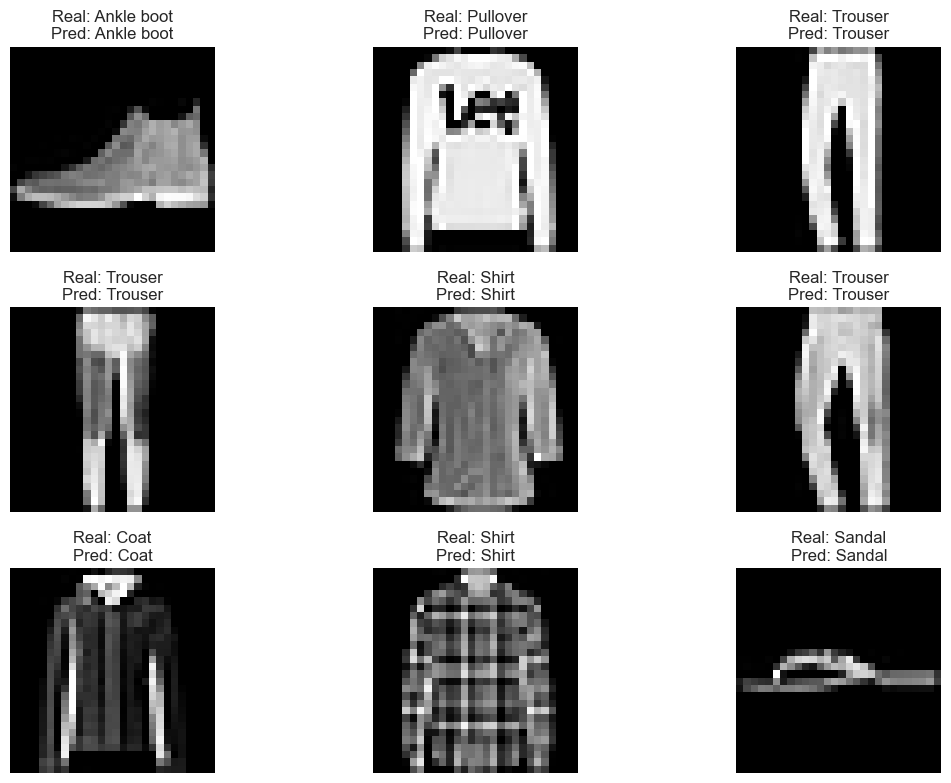

In [29]:
# Visualizar algunas predicciones
plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"Real: {class_names[y_test[i]]}\nPred: {class_names[y_pred[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.savefig("outputs/predicciones.png")
plt.show()

## Conclusión de L3

En esta lección se implementó una red neuronal convolutiva para clasificar imágenes de ropa del dataset Fashion-MNIST. La arquitectura CNN resultó adecuada porque permite extraer características espaciales relevantes de las imágenes, mejorando el desempeño frente a una red densa.

Además, se aplicaron técnicas de optimización y regularización como Adam, Dropout y EarlyStopping, logrando un modelo más robusto y con buena capacidad de generalización.

In [26]:
# Se guarda el modelo
model_l3.save("models/modelo_cnn_fashion_mnist.h5")